In [12]:
import numpy as np
import networkx as nx
from adiabatic_computation.time import ntime, S

def build_zermelo_graph(n):
    """
    Build directed graph for river crossing problem.
    
    Nodes: (col, row)
    Edges: forward only (col -> col+1)
    Weights: travel time from ntime()
    """
    G = nx.DiGraph()

    for col in range(n):
        for row in range(n):
            G.add_node((col, row))

    for col in range(n - 1):
        t_up, t_straight, t_down = ntime(col + 1, n)

        # also compute physical quantities (optional)
        dx = D / n
        x_k = (col + 0.5) * dx
        current = S(x_k)

        for row in range(n):
            src = (col, row)

            # up-right
            if row < n - 1:
                G.add_edge(
                    src, (col + 1, row + 1),
                    weight=t_up,
                    move="up",
                    current=current
                )

            # straight
            G.add_edge(
                src, (col + 1, row),
                weight=t_straight,
                move="straight",
                current=current
            )

            # down-right
            if row > n - 1:
                G.add_edge(
                    src, (col + 1, row - 1),
                    weight=t_down,
                    move="down",
                    current=current
                )

    return G

n = 12
G = build_zermelo_graph(n)

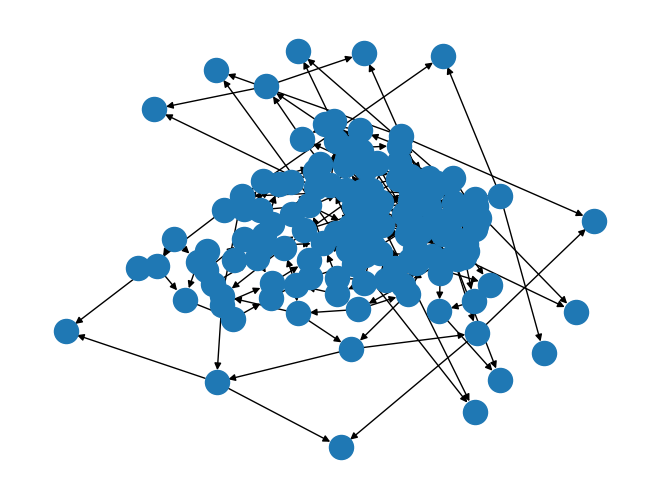

In [13]:
import matplotlib.pyplot as plt
nx.draw(G)
plt.show()

In [14]:
best_cost = np.inf
best_path = None

for start_row in range(n):
    for end_row in range(n):
        try:
            cost = nx.shortest_path_length(
                G,
                source=(0, start_row),
                target=(n-1, end_row),
                weight="weight"
            )
            if cost < best_cost:
                best_cost = cost
                best_path = nx.shortest_path(
                    G,
                    source=(0, start_row),
                    target=(n-1, end_row),
                    weight="weight"
                )
        except nx.NetworkXNoPath:
            pass

print("Best path:", best_path)
print("Best cost:", best_cost)

Best path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0)]
Best cost: 1.5768845179607858
